In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/uk-accident-data/uk_accident.csv
/kaggle/input/road-accident-dataset/Road Accident Data.csv
/kaggle/input/road-accident-dataset/Road Accident Data.xlsx
/kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv


In [2]:
!pip install -U scikit-learn imbalanced-learn


In [3]:
# Step 1: Import Libraries
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Version check
import sklearn, imblearn
print("✅ scikit-learn version:", sklearn.__version__)
print("✅ imbalanced-learn version:", imblearn.__version__)


✅ scikit-learn version: 1.7.2
✅ imbalanced-learn version: 0.14.0


In [4]:
file_path = "/kaggle/input/road-accident-dataset/Road Accident Data.csv"
df = pd.read_csv(file_path)
df.head

<bound method NDFrame.head of        Accident_Index Accident Date Month Day_of_Week  Year  \
0       200901BS70001      1/1/2021   Jan    Thursday  2021   
1       200901BS70002      1/5/2021   Jan      Monday  2021   
2       200901BS70003      1/4/2021   Jan      Sunday  2021   
3       200901BS70004      1/5/2021   Jan      Monday  2021   
4       200901BS70005      1/6/2021   Jan     Tuesday  2021   
...               ...           ...   ...         ...   ...   
307968  201091NM01760     2/18/2022   Feb    Thursday  2022   
307969  201091NM01881     2/21/2022   Feb      Sunday  2022   
307970  201091NM01935     2/23/2022   Feb     Tuesday  2022   
307971  201091NM01964     2/23/2022   Feb     Tuesday  2022   
307972  201091NM02142     2/28/2022   Feb      Sunday  2022   

                    Junction_Control                      Junction_Detail  \
0           Give way or uncontrolled              T or staggered junction   
1           Give way or uncontrolled                       

In [5]:

df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [6]:
print("Null values per column:\n", df.isnull().sum())

Null values per column:
 Accident_Index                     0
Accident Date                      0
Month                              0
Day_of_Week                        0
Year                               0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions          317
Road_Type                       1534
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions              6057
Vehicle_Type                       0
dtype: int64


In [7]:
# Fill missing values with mode for categorical & median for numeric
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_167/2742319241.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_167/2742319241.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [8]:
# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [9]:

# Step 4: Feature & Target
# ============================
target_col = "Accident_Severity"  # adjust if needed
X = df.drop(target_col, axis=1)
y = df[target_col]

# Scale features (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
print("Null values per column:\n", df.isnull().sum())

Null values per column:
 Accident_Index                0
Accident Date                 0
Month                         0
Day_of_Week                   0
Year                          0
Junction_Control              0
Junction_Detail               0
Accident_Severity             0
Latitude                      0
Light_Conditions              0
Local_Authority_(District)    0
Carriageway_Hazards           0
Longitude                     0
Number_of_Casualties          0
Number_of_Vehicles            0
Police_Force                  0
Road_Surface_Conditions       0
Road_Type                     0
Speed_limit                   0
Time                          0
Urban_or_Rural_Area           0
Weather_Conditions            0
Vehicle_Type                  0
dtype: int64


In [11]:
# Step 5: Define Models
# ============================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGB Classifier": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "CatBoost Classifier": CatBoostClassifier(verbose=0, random_state=42),
    "LightGBM Classifier": LGBMClassifier(random_state=42)
}

# SMOTE for balancing
smote = SMOTE(random_state=42)

In [12]:
# Step 6: Evaluation Functions
# ============================
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return acc, prec, rec, f1, report, cm

def display_results(model_name, metrics, title):
    acc, prec, rec, f1, report, cm = metrics
    print(f"\n=== {model_name} - {title} ===")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
    print("Classification Report:\n", report)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"{model_name} - {title}")
    plt.show()
    return acc, prec, rec, f1  # return for summary table



================ Running Random Forest =================

=== Random Forest - Imbalanced Data ===
Accuracy: 0.8547, Precision: 0.7952, Recall: 0.8547, F1: 0.7904
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.01      0.02       791
           1       0.41      0.01      0.02      8148
           2       0.86      1.00      0.92     52656

    accuracy                           0.85     61595
   macro avg       0.66      0.34      0.32     61595
weighted avg       0.80      0.85      0.79     61595



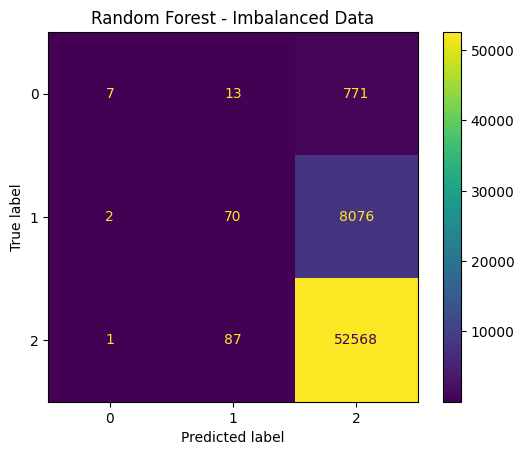


=== Random Forest - Balanced Data ===
Accuracy: 0.9483, Precision: 0.9504, Recall: 0.9483, F1: 0.9482
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     52656
           1       0.97      0.88      0.92     52656
           2       0.89      0.97      0.93     52656

    accuracy                           0.95    157968
   macro avg       0.95      0.95      0.95    157968
weighted avg       0.95      0.95      0.95    157968



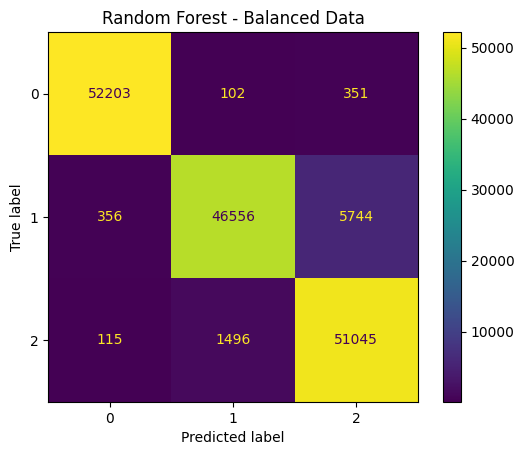



================ Running Gradient Boosting =================

=== Gradient Boosting - Imbalanced Data ===
Accuracy: 0.8552, Precision: 0.8182, Recall: 0.8552, F1: 0.7892
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.03      0.05       791
           1       0.58      0.00      0.00      8148
           2       0.86      1.00      0.92     52656

    accuracy                           0.86     61595
   macro avg       0.75      0.34      0.33     61595
weighted avg       0.82      0.86      0.79     61595



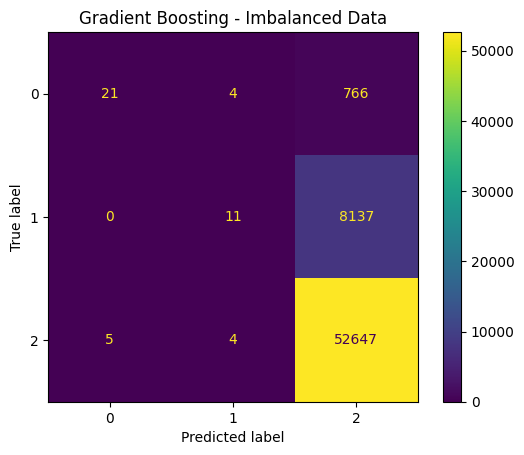


=== Gradient Boosting - Balanced Data ===
Accuracy: 0.7163, Precision: 0.7080, Recall: 0.7163, F1: 0.7018
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.72     52656
           1       0.67      0.46      0.55     52656
           2       0.75      0.96      0.84     52656

    accuracy                           0.72    157968
   macro avg       0.71      0.72      0.70    157968
weighted avg       0.71      0.72      0.70    157968



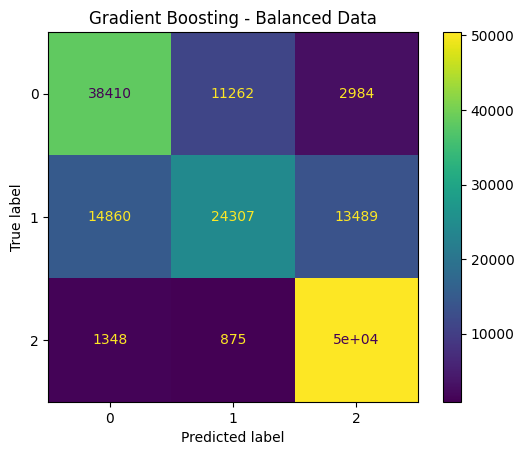



================ Running K-Nearest Neighbors =================

=== K-Nearest Neighbors - Imbalanced Data ===
Accuracy: 0.8352, Precision: 0.7631, Recall: 0.8352, F1: 0.7899
Classification Report:
               precision    recall  f1-score   support

           0       0.08      0.01      0.02       791
           1       0.21      0.05      0.09      8148
           2       0.86      0.97      0.91     52656

    accuracy                           0.84     61595
   macro avg       0.38      0.34      0.34     61595
weighted avg       0.76      0.84      0.79     61595



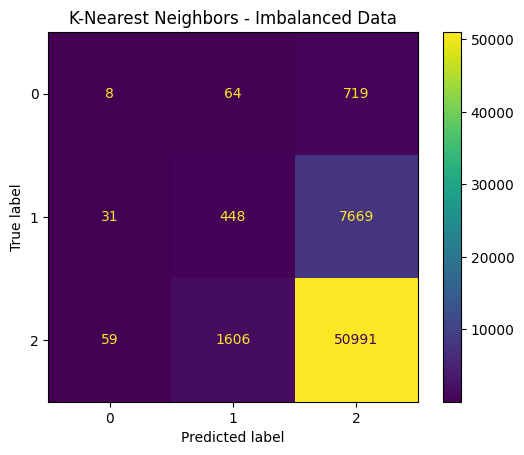


=== K-Nearest Neighbors - Balanced Data ===
Accuracy: 0.8508, Precision: 0.8770, Recall: 0.8508, F1: 0.8413
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     52656
           1       0.74      0.98      0.84     52656
           2       0.97      0.58      0.72     52656

    accuracy                           0.85    157968
   macro avg       0.88      0.85      0.84    157968
weighted avg       0.88      0.85      0.84    157968



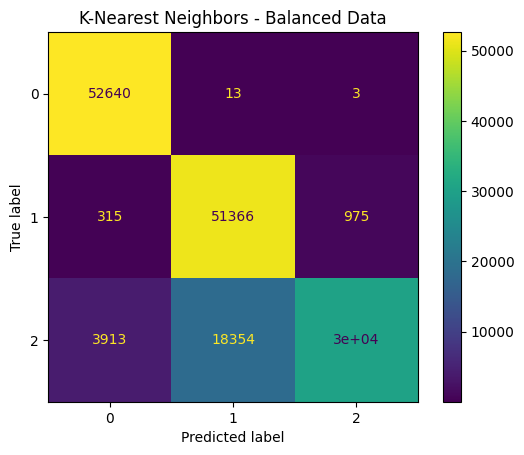



================ Running XGB Classifier =================

=== XGB Classifier - Imbalanced Data ===
Accuracy: 0.8554, Precision: 0.8048, Recall: 0.8554, F1: 0.7940
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.03      0.05       791
           1       0.50      0.02      0.04      8148
           2       0.86      1.00      0.92     52656

    accuracy                           0.86     61595
   macro avg       0.61      0.35      0.34     61595
weighted avg       0.80      0.86      0.79     61595



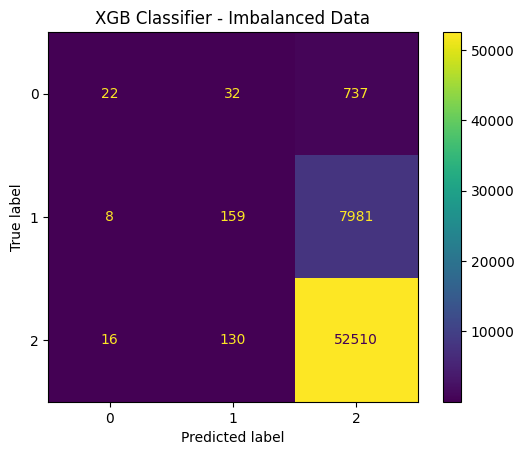


=== XGB Classifier - Balanced Data ===
Accuracy: 0.8324, Precision: 0.8346, Recall: 0.8324, F1: 0.8254
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85     52656
           1       0.85      0.63      0.73     52656
           2       0.82      0.99      0.90     52656

    accuracy                           0.83    157968
   macro avg       0.83      0.83      0.83    157968
weighted avg       0.83      0.83      0.83    157968



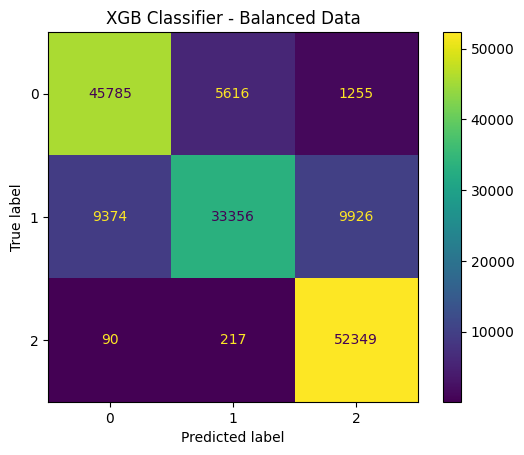



================ Running CatBoost Classifier =================

=== CatBoost Classifier - Imbalanced Data ===
Accuracy: 0.8562, Precision: 0.8155, Recall: 0.8562, F1: 0.7946
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.03      0.06       791
           1       0.55      0.02      0.04      8148
           2       0.86      1.00      0.92     52656

    accuracy                           0.86     61595
   macro avg       0.73      0.35      0.34     61595
weighted avg       0.82      0.86      0.79     61595



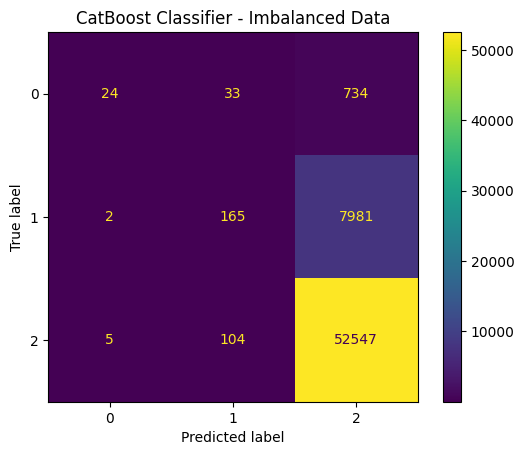


=== CatBoost Classifier - Balanced Data ===
Accuracy: 0.8522, Precision: 0.8552, Recall: 0.8522, F1: 0.8466
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87     52656
           1       0.88      0.67      0.76     52656
           2       0.84      1.00      0.91     52656

    accuracy                           0.85    157968
   macro avg       0.86      0.85      0.85    157968
weighted avg       0.86      0.85      0.85    157968



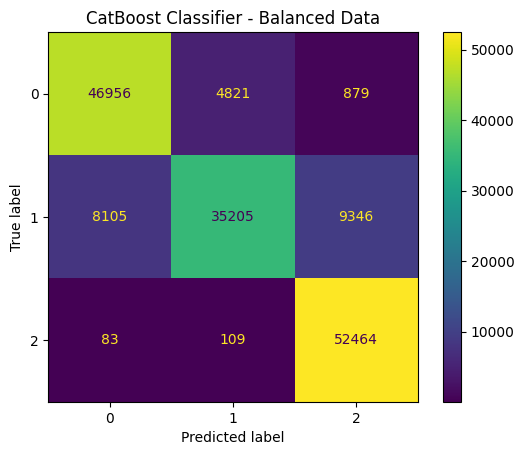



================ Running LightGBM Classifier =================
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1712
[LightGBM] [Info] Number of data points in the train set: 246378, number of used features: 22
[LightGBM] [Info] Start training from score -4.355662
[LightGBM] [Info] Start training from score -2.022800
[LightGBM] [Info] Start training from score -0.156792


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Classifier - Imbalanced Data ===
Accuracy: 0.8560, Precision: 0.8183, Recall: 0.8560, F1: 0.7929
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.03      0.06       791
           1       0.60      0.01      0.03      8148
           2       0.86      1.00      0.92     52656

    accuracy                           0.86     61595
   macro avg       0.65      0.35      0.34     61595
weighted avg       0.82      0.86      0.79     61595



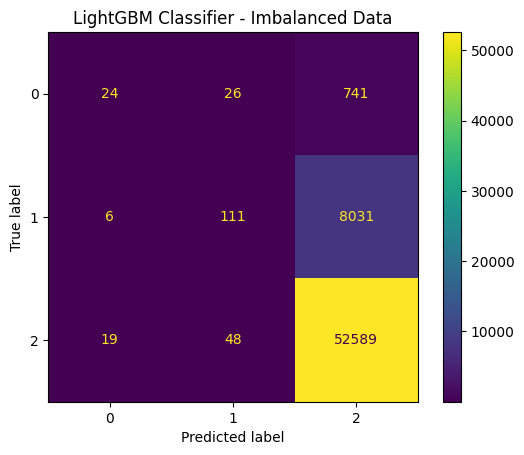

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5380
[LightGBM] [Info] Number of data points in the train set: 631872, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Classifier - Balanced Data ===
Accuracy: 0.8036, Precision: 0.8018, Recall: 0.8036, F1: 0.7945
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81     52656
           1       0.80      0.59      0.67     52656
           2       0.83      1.00      0.90     52656

    accuracy                           0.80    157968
   macro avg       0.80      0.80      0.79    157968
weighted avg       0.80      0.80      0.79    157968



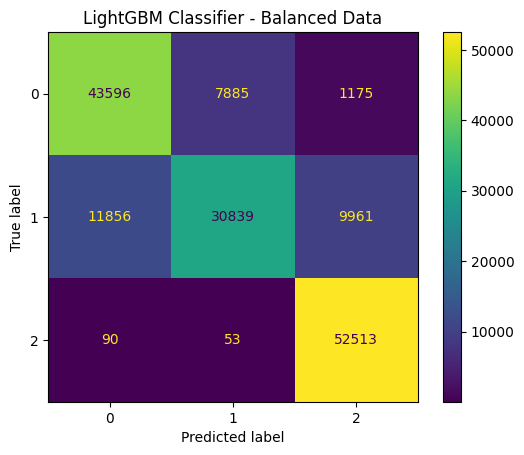

In [13]:
# Step 7: Run Models Individually
# ============================
summary_results = []

for name, model in models.items():
    print(f"\n\n================ Running {name} =================")
    
    # ---- Imbalanced Data ----
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
    metrics_imbal = evaluate_model(model, X_train, X_test, y_train, y_test)
    acc, prec, rec, f1 = display_results(name, metrics_imbal, "Imbalanced Data")
    summary_results.append([name, "Imbalanced", acc, prec, rec, f1])
    
    # ---- Balanced Data ----
    X_bal, y_bal = smote.fit_resample(X_scaled, y)
    X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)
    metrics_bal = evaluate_model(model, X_train_bal, X_test_bal, y_train_bal, y_test_bal)
    acc, prec, rec, f1 = display_results(name, metrics_bal, "Balanced Data")
    summary_results.append([name, "Balanced", acc, prec, rec, f1])
